In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("genres_v2.csv",low_memory=False)

In [4]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
y = df['genre']

In [6]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5448528542725446


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6498049875901194


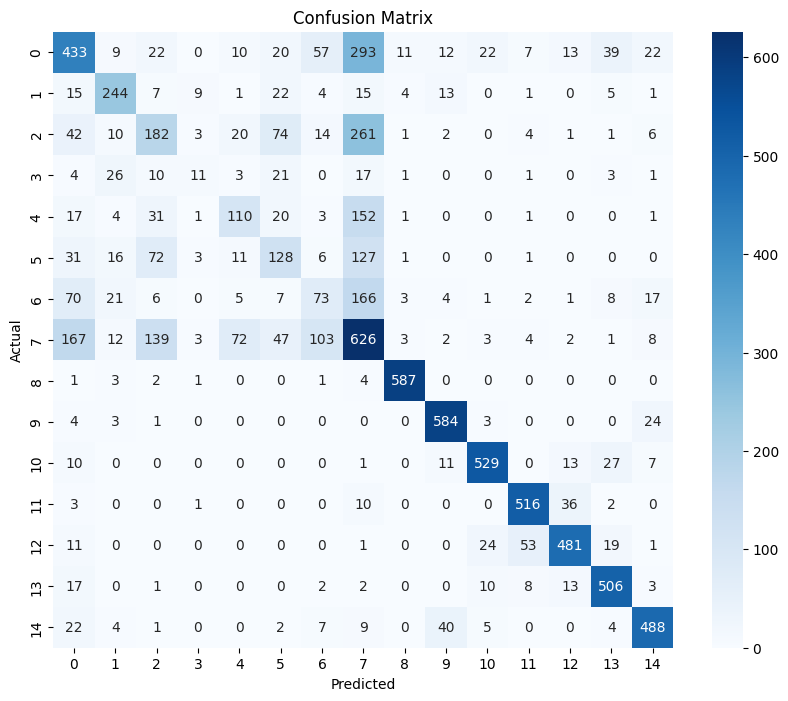

In [9]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.51      0.45      0.48       970
           1       0.69      0.72      0.70       341
           2       0.38      0.29      0.33       621
           3       0.34      0.11      0.17        98
           4       0.47      0.32      0.38       341
           5       0.38      0.32      0.35       396
           6       0.27      0.19      0.22       384
           7       0.37      0.53      0.44      1192
           8       0.96      0.98      0.97       599
           9       0.87      0.94      0.91       619
          10       0.89      0.88      0.89       598
          11       0.86      0.91      0.89       568
          12       0.86      0.82      0.84       590
          13       0.82      0.90      0.86       562
          14       0.84      0.84      0.84       582

    accuracy                           0.65      8461
   macro avg       0.64      0.61      0.62      8461
weighted avg       0.64   

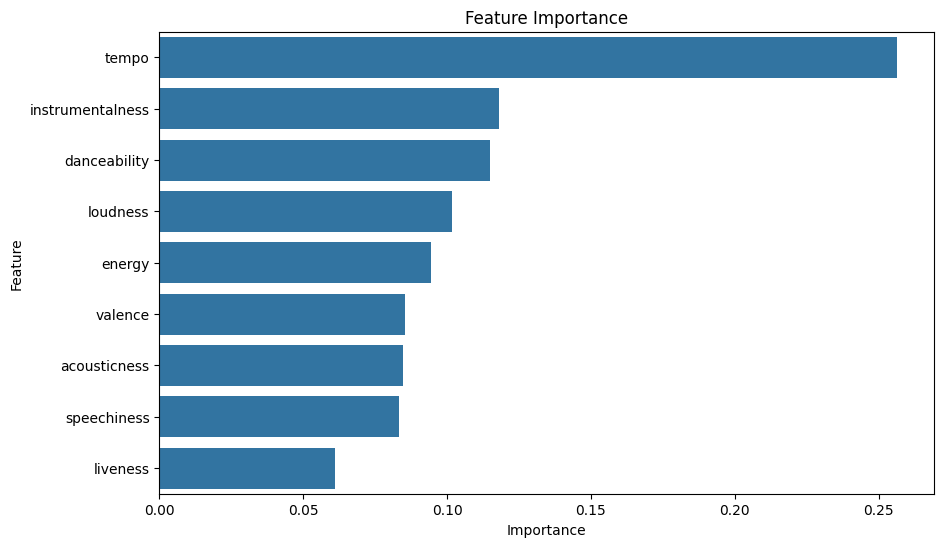

In [11]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

Insights
1. Random Forest achieved higher
accuracy than Decision Tree.
2. Energy and danceability were among the most influential features in genre prediction.
3. The confusion matrix showed some genres were easier to classify than others.
4. Machine learning models can effectively identify patterns in music audio characteristics.